In [4]:
import pickle
import xarray as xr
from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs

/tmp/ipykernel_11789/747203138.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mpf = np.array(Dataset('inputs/mpf.nc')['melt_pond_fraction_filled'])/100


(array([2.8407e+04, 8.3160e+03, 2.8570e+03, 7.6700e+02, 2.0000e+02,
        3.8000e+01, 7.0000e+00, 1.0000e+00, 4.0000e+00, 4.0000e+00]),
 array([0.        , 0.03954006, 0.07908011, 0.11862017, 0.15816022,
        0.19770028, 0.23724034, 0.2767804 , 0.31632045, 0.3558605 ,
        0.39540055]),
 <BarContainer object of 10 artists>)

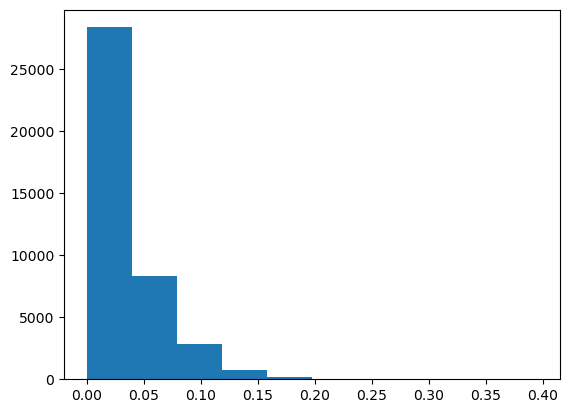

In [5]:
mpf = np.array(Dataset('inputs/mpf.nc')['melt_pond_fraction_filled'])/100
plt.hist(mpf.flatten())

/tmp/ipykernel_11789/1308780674.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  rf = np.array(Dataset('inputs/rf.nc')['ridged_fraction_filled'])


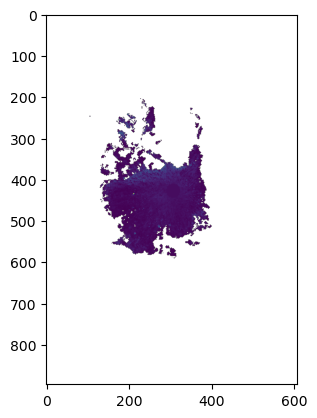

In [6]:
rf = np.array(Dataset('inputs/rf.nc')['ridged_fraction_filled'])
plt.imshow(rf)

In [7]:
grid_d = Dataset('../aux_data/NSIDC0771_LatLon_PS_N12.5km_v1.1.nc')
lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])
psn_lon = np.fliplr(np.rot90(np.rot90(lon)))
psn_lat = np.fliplr(np.rot90(np.rot90(lat)))

/tmp/ipykernel_11789/1214246585.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])


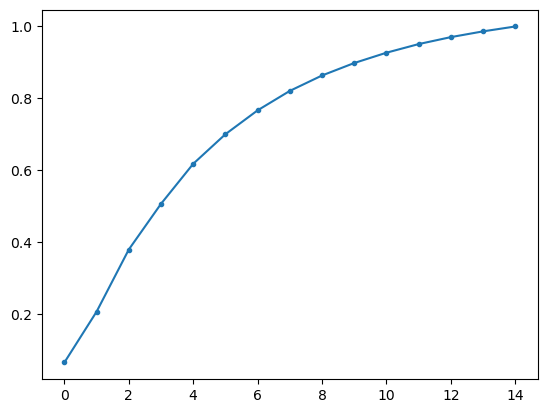

In [8]:
hpdf = [0.0646, 0.1415, 0.173, 0.1272, 0.1114, 0.0824, 0.0665, \
         0.0541, 0.0429, 0.0347, 0.0287, 0.024,0.0194, 0.016, 0.0136]

plt.plot(np.cumsum(hpdf),marker='.')

In [9]:
thresh = 1-rf

args = [np.argmax(np.cumsum(hpdf)>t)  if ~np.isnan(t) else np.nan for t in thresh.flatten()]

args = np.array(args).reshape(thresh.shape)

In [10]:
d = Dataset('inputs/snow_dists_array.nc')
snow_dists = d['snow_dists']
depth_cols = d['snow_depths']

In [11]:
# pickle.dump((mpf,rf,args,psn_lon,psn_lat),open('fractions.p','wb'))

ds = xr.DataArray(name='args',
    data=args,
    coords={'latitude':(['x','y'],d['latitude']),
            'longitude':(['x','y'],d['longitude']),
           },
                  
    dims=['x','y'],
)

ds.to_netcdf('inputs/args.nc')
ds.to_netcdf('/home/robbie/uit_mnt/home/romal7177/algae/inputs/args.nc')

getfattr: Removing leading '/' from absolute path names
getfattr: /home/robbie/uit_mnt/home/romal7177/algae/inputs/args.nc: Operation not supported


# Make some figures

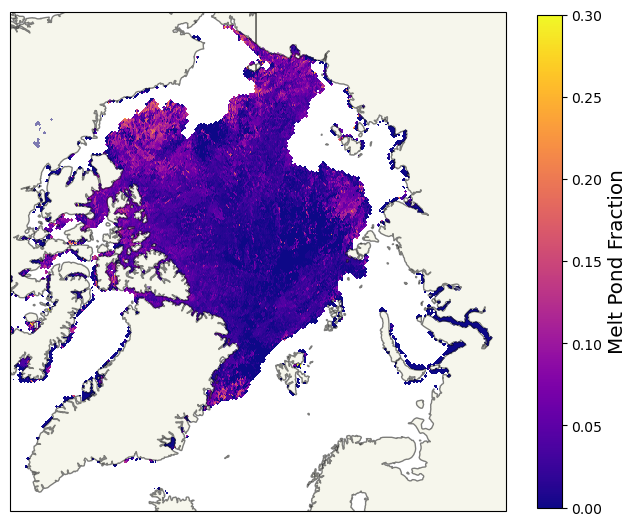

In [12]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)
m = ax.pcolormesh(d['longitude'],
                  d['latitude'],
                  mpf,
                  vmin = 0,
                  vmax = 0.3,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

cb=fig.colorbar(m,shrink=0.8)
cb.set_label('Melt Pond Fraction',fontsize='x-large')
plt.savefig('../figs/mpf.png',dpi=500,bbox_inches='tight')

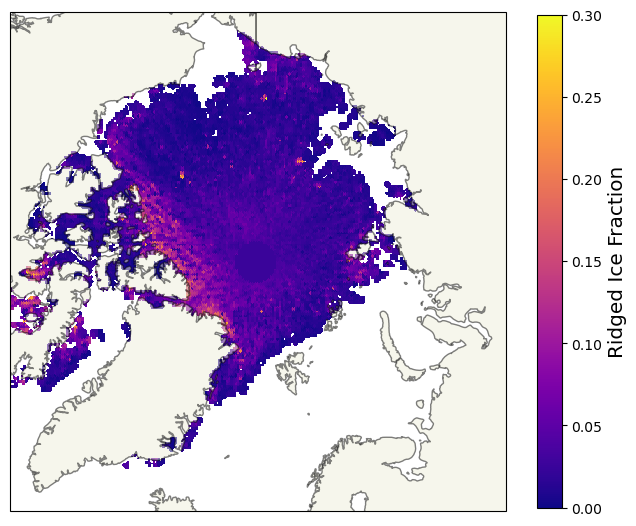

In [14]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)
m = ax.pcolormesh(d['longitude'],
                  d['latitude'],
                  rf,
                  vmin = 0,
                  vmax = 0.3,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

cb=fig.colorbar(m,shrink=0.8)
cb.set_label('Ridged Ice Fraction',fontsize='x-large')
plt.savefig('../figs/rf.png',dpi=500,bbox_inches='tight')

In [16]:
1.3**0.6, 5**0.6

(1.1704854282221195, 2.626527804403767)